In [2]:
%load_ext autoreload
%autoreload 2

import sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy
import seaborn as sns
import h5py
from plotting_utils import FlatmapMapper, FigureConfig, FlatmapPlotter, SingleCorrelationStrategy, LoserTakesItAllStrategy
import nibabel as nib
from pathlib import Path
root_dir = Path('../')
sys.path.append('../')
from data_loading import (
    DataSequence, ContextManager, EmbeddingManager, 
    file_io, config, prepare_data, preprocessing
)


In [3]:
def get_significant_voxels(results, mode):
    sig = np.array(results[mode]['r'])
    sig[results[mode]['fdr']['r']['excluded_voxels_indices']] = np.nan
    return sig

## FSAverage

In [38]:
language_rois = ['AG', 'ATL', 'PTL', 'IFG', 'MFG', 'IFGOrb', 'PCC', 'dmPFC']
def load_sparse_array(fname, varname):
    """Load a numpy sparse array from an hdf file"""
    with h5py.File(fname) as hf:
        data = (
            hf["%s_data" % varname],
            hf["%s_indices" % varname],
            hf["%s_indptr" % varname],
        )
        sparsemat = scipy.sparse.csr_matrix(data, shape=hf["%s_shape" % varname])
    return sparsemat
def map_data_to_fsaverage(voxels: np.ndarray, map_file: str) -> np.ndarray:
    pixmap = load_sparse_array(map_file, "voxel_to_fsaverage")
    badmask = np.array(pixmap.sum(1) > 0).ravel()
    mimg = (np.nan * np.ones(badmask.shape)).astype(voxels.dtype)
    mimg[badmask] = (pixmap * voxels.ravel())[badmask].astype(mimg.dtype)
    return mimg  # no .T[::-1]

from scipy.spatial import cKDTree
import cortex

def get_language_mask(roi, return_fs7=True):
    language_rois = ['AG', 'ATL', 'PTL', 'IFG', 'MFG', 'IFGOrb', 'PCC', 'dmPFC']
    roi_indices = {'AG': [149, 150, 151, 140, 141],
                    'ATL': [123, 131, 132, 134, 172, 128, 176],
                    'PTL': [129, 125, 139, 25, 28, 175, 130],
                    'IFG': [74, 75, 79, 81],
                    'MFG': [12],
                    'IFGOrb': [77, 171, 85],
                    'PCC': [161, 162, 27, 30, 32, 33, 34, 14],
                    'dmPFC': [69, 62, 72]}
    import nibabel as nib
    if return_fs7:
        language_mask = []
        path_to_lh_annot = root_dir/config.DATA_DIR/'fsaverage'/'lh.HCP-MMP1.annot'
        path_to_rh_annot = root_dir/config.DATA_DIR/'fsaverage'/'rh.HCP-MMP1.annot'
        lh_annot = nib.freesurfer.io.read_annot(path_to_lh_annot)
        rh_annot = nib.freesurfer.io.read_annot(path_to_rh_annot)
        language_mask = np.zeros(327684, dtype=bool)
        for index in roi_indices[roi]:
            language_mask[np.where(lh_annot[0] == index)[0]] = 1
            language_mask[163842+np.where(rh_annot[0] == index)[0]] = 1
        return language_mask

In [40]:
results = file_io.load_results(
    root_dir / config.OUTPUT_DIR / 'results_actual',
    'listening',
    'subject07'
)
map_file = root_dir / 'data' / 'mappers'/'subject07_mappers.hdf'
test = get_significant_voxels(results, 'baseline')
data = map_data_to_fsaverage(voxels=test, map_file=map_file)

In [41]:
def foo(subject, modality):
    results = file_io.load_results(
        root_dir / config.OUTPUT_DIR / 'results_actual',
        modality,
        subject
    )
    map_file = root_dir / 'data' / 'mappers'/f'{subject}_mappers.hdf'
    
    verbs = get_significant_voxels(results, "verb")
    nouns = get_significant_voxels(results, "noun")
    baseline = get_significant_voxels(results, "baseline")

    verbs = map_data_to_fsaverage(verbs, map_file)
    nouns = map_data_to_fsaverage(nouns, map_file)
    baseline = map_data_to_fsaverage(baseline, map_file)
    
    return verbs, nouns, baseline

In [48]:
import warnings
def plot_winner_map(results, modality='listening', roi='AG'):
    # vol = cortex.Vertex(data, subject='fsaverage')
    vertex_data = np.zeros(327684)  # fsaverage has 327684 vertices (both hemispheres)
    roi_vertex_indices = get_language_mask(roi)  # get vertex indices for your ROI
    vertex_data[:163842] = 0
    vertex_data[100000:] = 1
    
    vertex_data[roi_vertex_indices] = 0.5  # mark your ROI
    d_verbs_list = []
    d_nouns_list = []
    
    for subject in [config.SUBJECTS[6]]:
        try:
            verb, noun, base = foo(subject, modality)
            d_verbs_list.append(base - verb)
            d_nouns_list.append(base - noun)
        except Exception as e:
            print(f"Skipping {subject}: {e}")
            continue
        
    if not d_verbs_list:
        raise RuntimeError("No subjects succeeded")
    
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        d_verbs = np.nanmean(np.vstack(d_verbs_list), axis=0)
        d_nouns = np.nanmean(np.vstack(d_nouns_list), axis=0)
    
    #d_verbs[~roi_vertex_indices] = np.nan
    #d_nouns[~roi_vertex_indices] = np.nan
    vol = cortex.Vertex2D(d_nouns,d_verbs, subject='fsaverage', vmin=0, vmax=0.1, vmin2=0, vmax2=0.1)
    fig=cortex.quickflat.make_figure(vol,with_curvature=True, )
    return fig

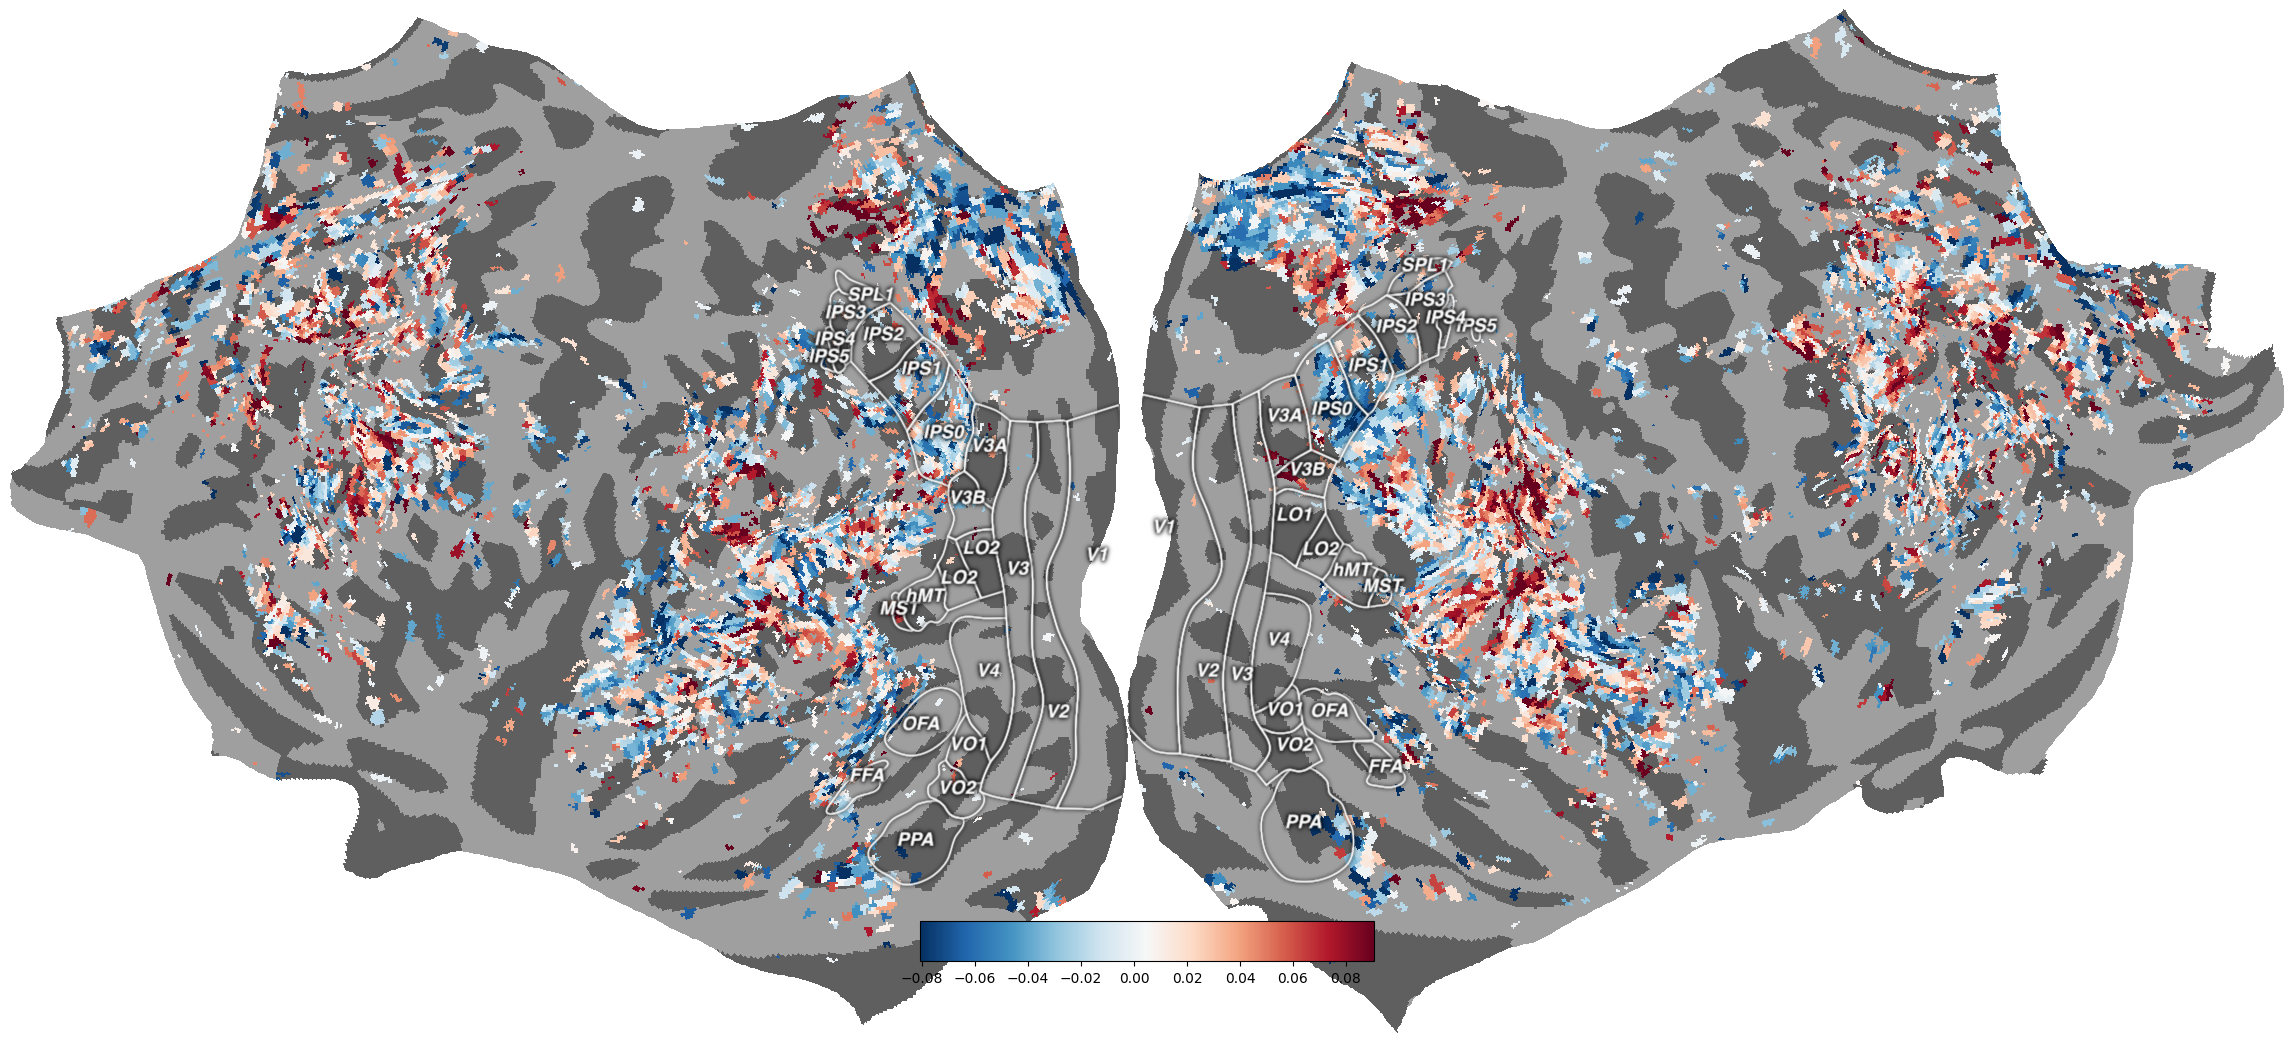

In [52]:
subject = 'subject07'
modality = 'listening'
verb, noun, base = foo(subject, modality)
d_verbs = base - verb
d_nouns = base - noun
vol = cortex.Vertex(d_verbs, subject='fsaverage')
fig = cortex.quickflat.make_figure(vol,with_curvature=True)
fig.savefig(root_dir / 'docs' / 'figures' / 'Presentation' / 'contrast_verb.pdf')

Skipping subject04: "Unable to synchronously open object (object 'voxel_to_fsaverage_data' doesn't exist)"
Skipping subject04: "Unable to synchronously open object (object 'voxel_to_fsaverage_data' doesn't exist)"


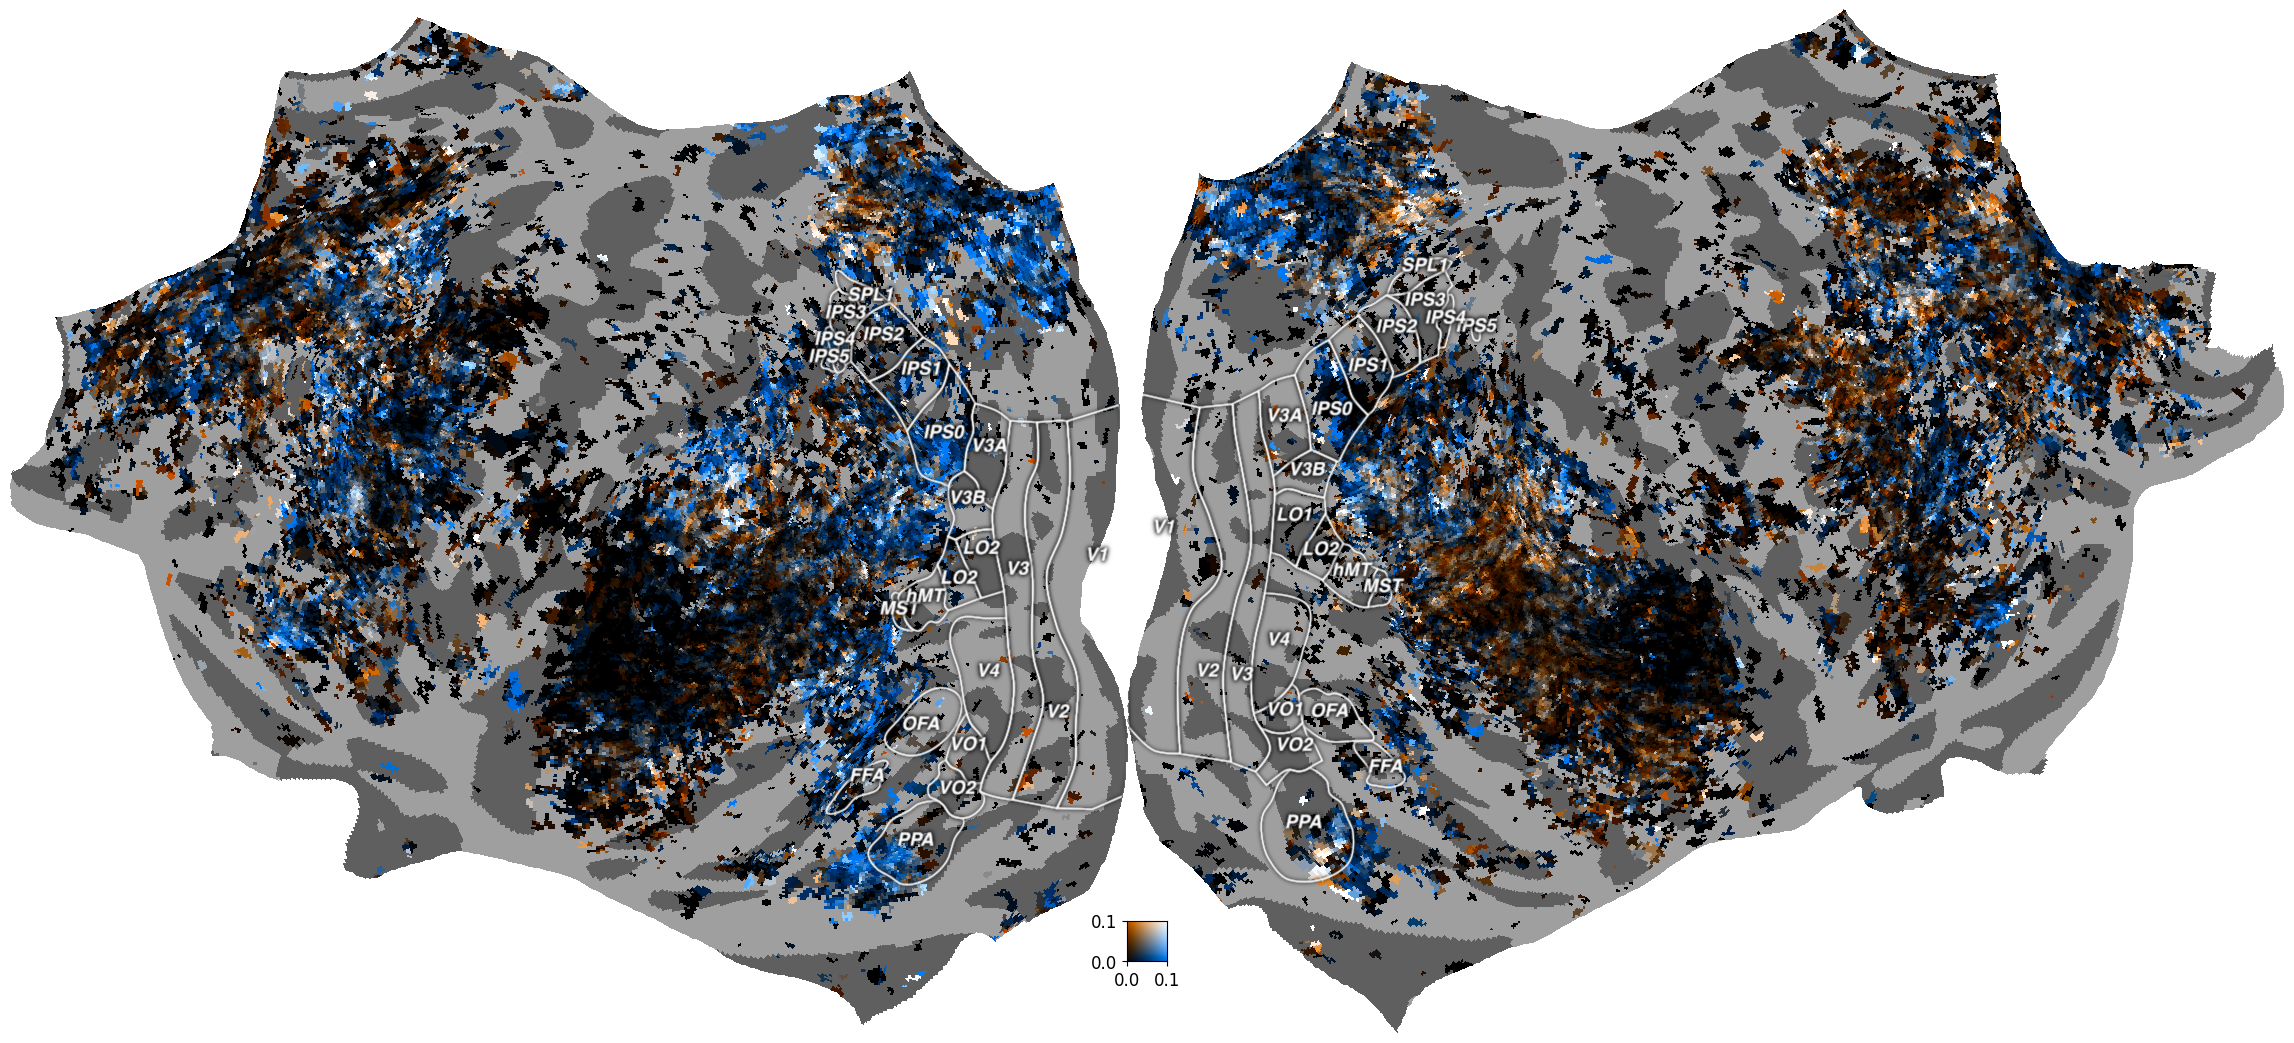

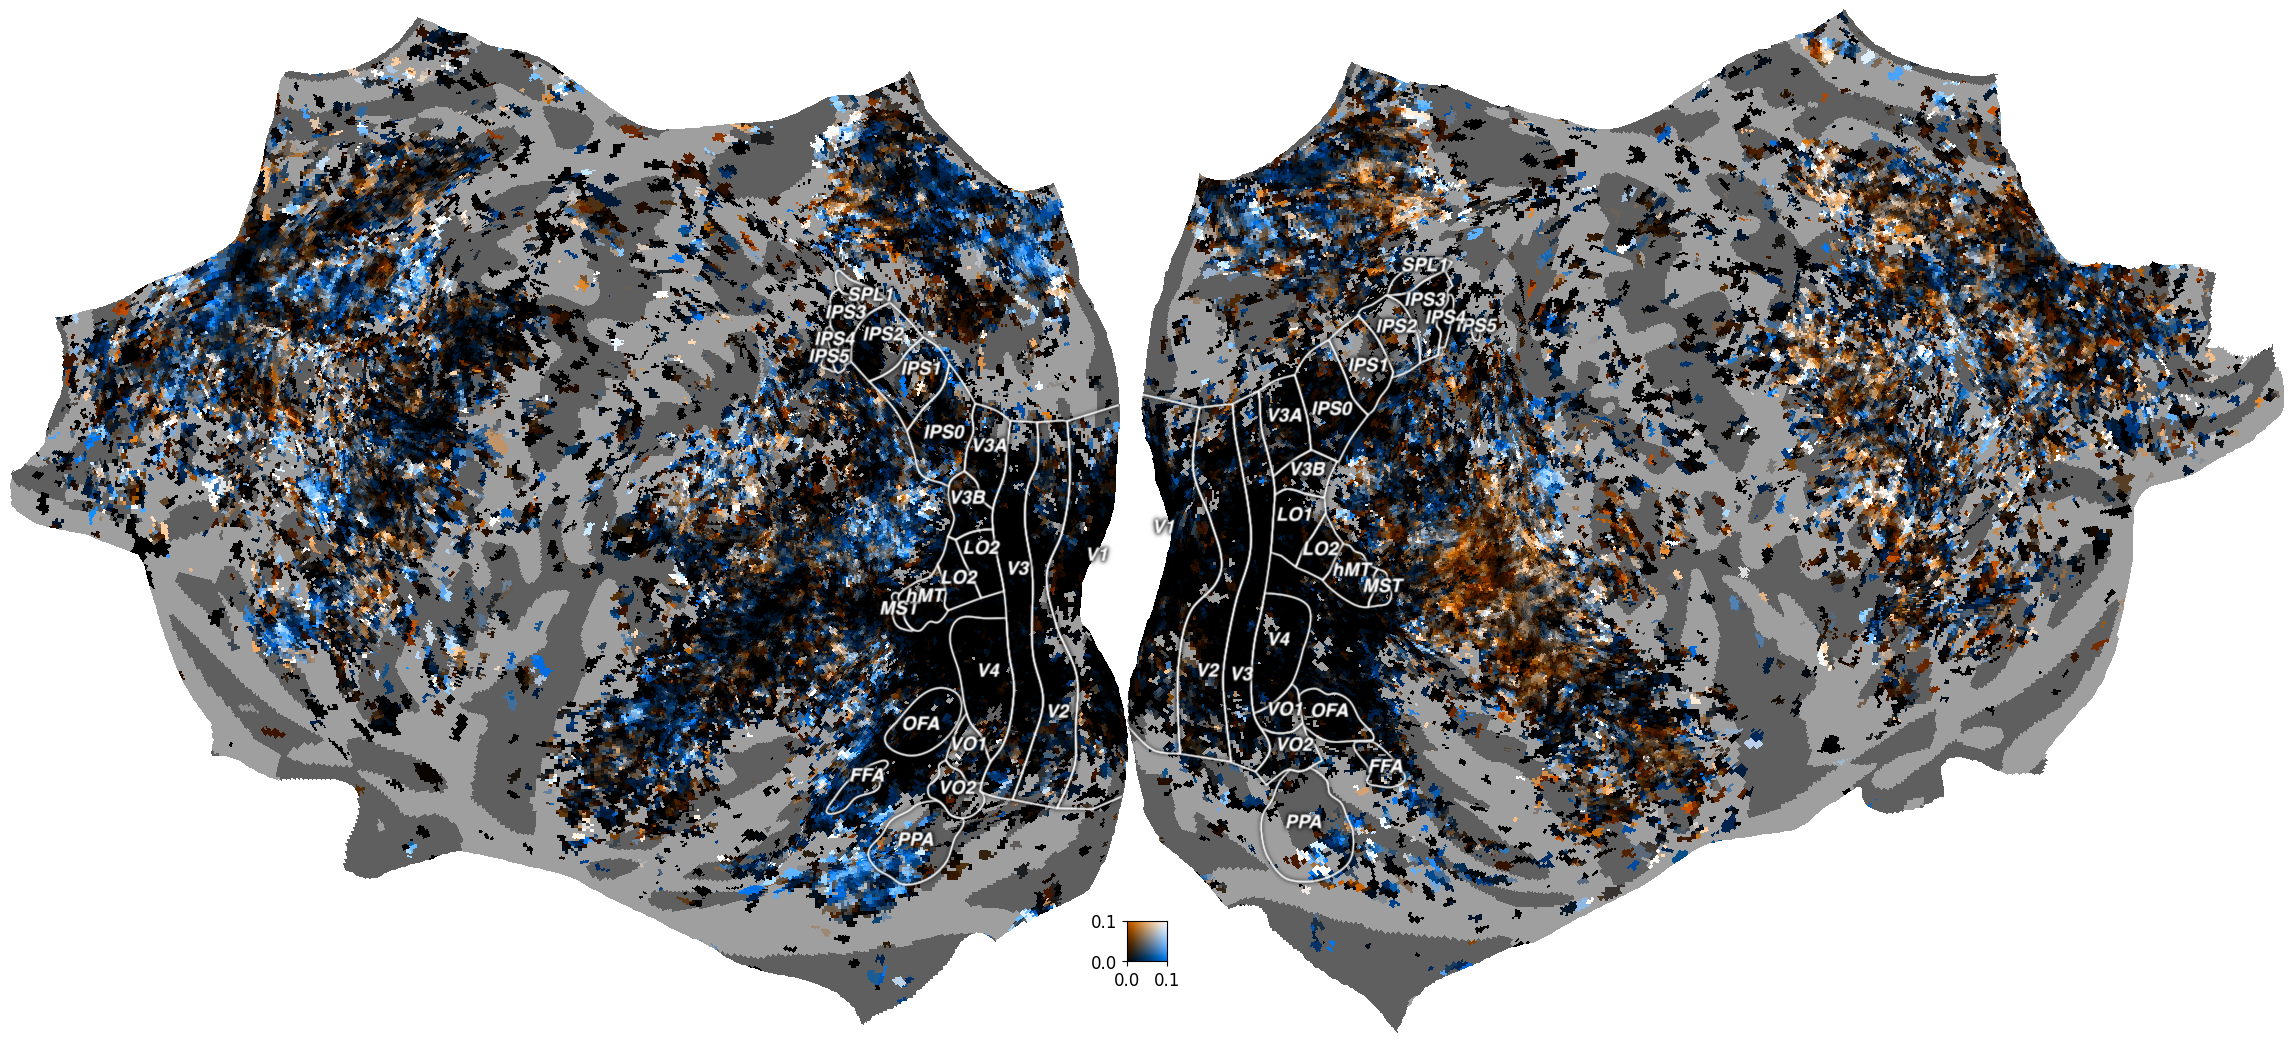

In [ ]:
fig = plot_winner_map(results)
fig_ = plot_winner_map(results, modality='reading')

#fig.savefig(root_dir / 'docs' / 'figures' / 'Presentation' / 'listening_winner_map.pdf')
#fig_.savefig(root_dir / 'docs' / 'figures' / 'Presentation' / 'reading_winner_map.pdf')

In [9]:
for roi in language_rois:
    plot_winner_map(results, roi, map_file)

KeyError: PosixPath('../data/mappers/subject07_mappers.hdf')

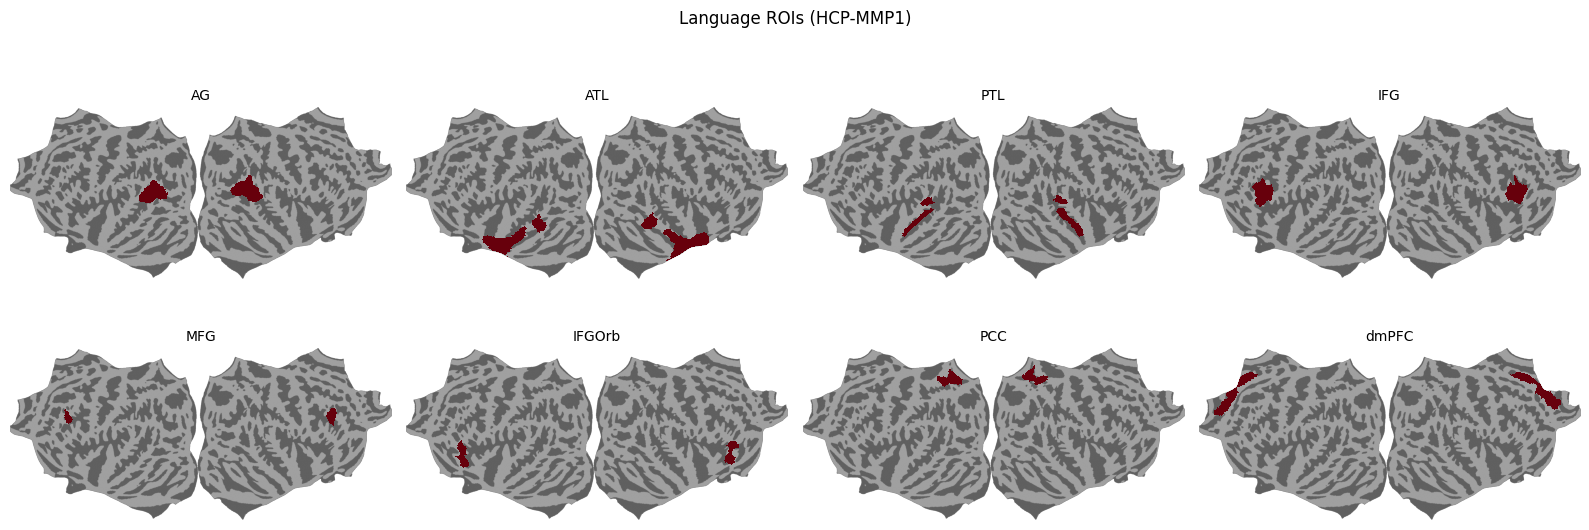

In [42]:
import numpy as np
import nibabel as nib
import cortex
import matplotlib.pyplot as plt

path = root_dir / 'data' / 'fsaverage'
lh_labels, lh_ctab, lh_names = nib.freesurfer.read_annot(path / 'lh.HCP-MMP1.annot')
rh_labels, rh_ctab, rh_names = nib.freesurfer.read_annot(path / 'rh.HCP-MMP1.annot')

lh_names_decoded = [n.decode() if isinstance(n, bytes) else n for n in lh_names]
rh_names_decoded = [n.decode() if isinstance(n, bytes) else n for n in rh_names]

# Map your ROI groups to HCP-MMP1 area names
# Adjust these to match whatever print(lh_names) showed you earlier
roi_area_names = {
    'AG':     ['L_PGi_ROI', 'L_PGp_ROI', 'L_PGs_ROI'],
    'ATL':    ['L_TE1a_ROI', 'L_TE1p_ROI', 'L_TGd_ROI'],
    'PTL':    ['L_STV_ROI', 'L_STSda_ROI', 'L_STSdp_ROI'],
    'IFG':    ['L_IFSa_ROI', 'L_IFSp_ROI', 'L_44_ROI', 'L_45_ROI'],
    'MFG':    ['L_p9-46v_ROI'],
    'IFGOrb': ['L_47l_ROI', 'L_47s_ROI'],
    'PCC':    ['L_31pd_ROI', 'L_31pv_ROI', 'L_PCV_ROI'],
    'dmPFC':  ['L_8BM_ROI', 'L_9m_ROI'],
}

def make_roi_mask(area_names, lh_labels, lh_names_decoded, rh_labels, rh_names_decoded):
    """Binary mask: 1.0 for ROI vertices, NaN elsewhere"""
    mask = np.full(len(lh_labels) + len(rh_labels), np.nan)
    for name in area_names:
        # try both lh and rh (and rh equivalent by replacing L_ with R_)
        for hemi, labels, names_decoded, offset in [
            ('lh', lh_labels, lh_names_decoded, 0),
            ('rh', rh_labels, rh_names_decoded, len(lh_labels)),
        ]:
            rh_name = name.replace('L_', 'R_')
            target = name if hemi == 'lh' else rh_name
            if target in names_decoded:
                idx = names_decoded.index(target)
                verts = np.where(labels == idx)[0]
                mask[offset + verts] = 1.0
    return mask

fig, axes = plt.subplots(2, 4, figsize=(16, 6))
axes = axes.flatten()

for ax, (roi_name, area_names) in zip(axes, roi_area_names.items()):
    mask = make_roi_mask(area_names, lh_labels, lh_names_decoded, rh_labels, rh_names_decoded)

    vol = cortex.Vertex(mask, subject='fsaverage', cmap='Reds', vmin=0, vmax=1)
    cortex.quickflat.make_figure(vol, with_curvature=True, with_rois=False, with_colorbar=False, fig=ax)
    ax.set_title(roi_name, fontsize=10)

plt.suptitle('Language ROIs (HCP-MMP1)', fontsize=12)
plt.tight_layout()
plt.savefig('language_rois.pdf', bbox_inches='tight')
plt.show()

In [ ]:
def plot_language_rois(rois=language_rois, output_path=None):
    ncols = 4
    nrows = int(np.ceil(len(rois) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3))
    axes = axes.flatten()

    for ax, roi in zip(axes, rois):
        mask = get_language_mask(roi).astype(float)  # (327684,) bool → float
        mask[mask == 0] = np.nan                      # non-ROI → transparent

        vol = cortex.Vertex(mask, subject='fsaverage', cmap='Reds', vmin=0, vmax=1)

        roi_fig = cortex.quickflat.make_figure(vol, with_curvature=True, with_rois=False, with_colorbar=False)

        roi_fig.canvas.draw()
        img = np.asarray(roi_fig.canvas.buffer_rgba())[..., :3]
        plt.close(roi_fig)

        ax.imshow(img)
        ax.set_title(roi, fontsize=10)
        ax.axis('off')

    for ax in axes[len(rois):]:
        ax.axis('off')

    plt.suptitle('Language ROIs (HCP-MMP1)', fontsize=13)
    plt.tight_layout()

    if output_path:
        plt.savefig(output_path, bbox_inches='tight', dpi=150)

    return fig



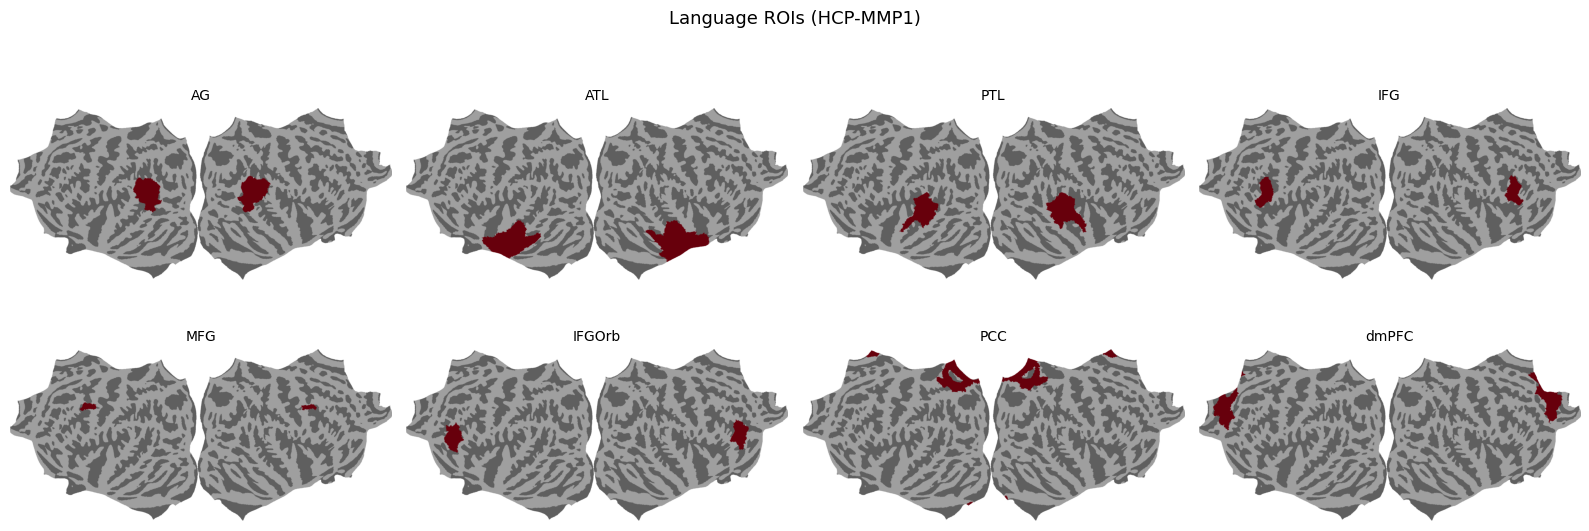

In [41]:
fig = plot_language_rois(
    rois=language_rois,
    output_path=root_dir /'docs' / 'figures'/'Tests'/ 'language_rois.pdf',
)
plt.show()

In [31]:
import warnings

def foo(subject, modality):
    results = file_io.load_results(
        root_dir / config.OUTPUT_DIR / 'results_actual',
        modality,
        subject
    )
    map_file = root_dir / 'data' / 'mappers'/f'{subject}_mappers.hdf'
    
    verbs = get_significant_voxels(results, "verb")
    nouns = get_significant_voxels(results, "noun")
    baseline = get_significant_voxels(results, "baseline")

    verbs = map_data_to_fsaverage(verbs, map_file)
    nouns = map_data_to_fsaverage(nouns, map_file)
    baseline = map_data_to_fsaverage(baseline, map_file)
    
    return verbs, nouns, baseline


def plot_winner_map_per_roi(modality='listening',
                            rois=language_rois,
                            output_path=None):
    # ── Aggregate across subjects ────────────────────────────────────────────
    d_verbs_list = []
    d_nouns_list = []

    for subject in config.SUBJECTS:
        try:
            verb, noun, base = foo(subject, modality)
            d_verbs_list.append(base - verb)
            d_nouns_list.append(base - noun)
        except Exception as e:
            print(f"Skipping {subject}: {e}")
            continue

    if not d_verbs_list:
        raise RuntimeError("No subjects succeeded")

    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        d_verbs = np.nanmean(np.vstack(d_verbs_list), axis=0)  # (327684,)
        d_nouns = np.nanmean(np.vstack(d_nouns_list), axis=0)  # (327684,)

    # ── One subplot per ROI ──────────────────────────────────────────────────
    ncols = 4
    nrows = int(np.ceil(len(rois) / ncols))
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(ncols * 4, nrows * 3))
    axes = axes.flatten()

    vmin, vmax = 0, 0.1

    for ax, roi in zip(axes, rois):
        mask = get_language_mask(roi)  # boolean array, shape (327684,)

        # Mask everything outside the ROI to NaN
        d_nouns_roi = np.full(327684, np.nan)
        d_verbs_roi = np.full(327684, np.nan)
        d_nouns_roi[mask] = d_nouns[mask]
        d_verbs_roi[mask] = d_verbs[mask]

        vol = cortex.Vertex2D(
            d_nouns_roi, d_verbs_roi,
            subject='fsaverage',
            vmin=vmin,  vmax=vmax,
            vmin2=vmin, vmax2=vmax,
        )

        roi_fig = cortex.quickflat.make_figure(
            vol,
            with_curvature=True,
            with_rois=False,
        )

        # Grab the rendered image and paste into subplot
        roi_fig.canvas.draw()
        img = np.asarray(roi_fig.canvas.buffer_rgba())[..., :3]  # drop alpha → RGB
        plt.close(roi_fig)

        ax.imshow(img)
        ax.set_title(roi, fontsize=10)
        ax.axis('off')

    # Hide any unused subplots
    for ax in axes[len(rois):]:
        ax.axis('off')

    plt.suptitle(f'Δr per ROI — {modality}', fontsize=13)
    plt.tight_layout()

    if output_path:
        plt.savefig(output_path, bbox_inches='tight', dpi=150)

    return fig

Skipping subject04: "Unable to synchronously open object (object 'voxel_to_fsaverage_data' doesn't exist)"


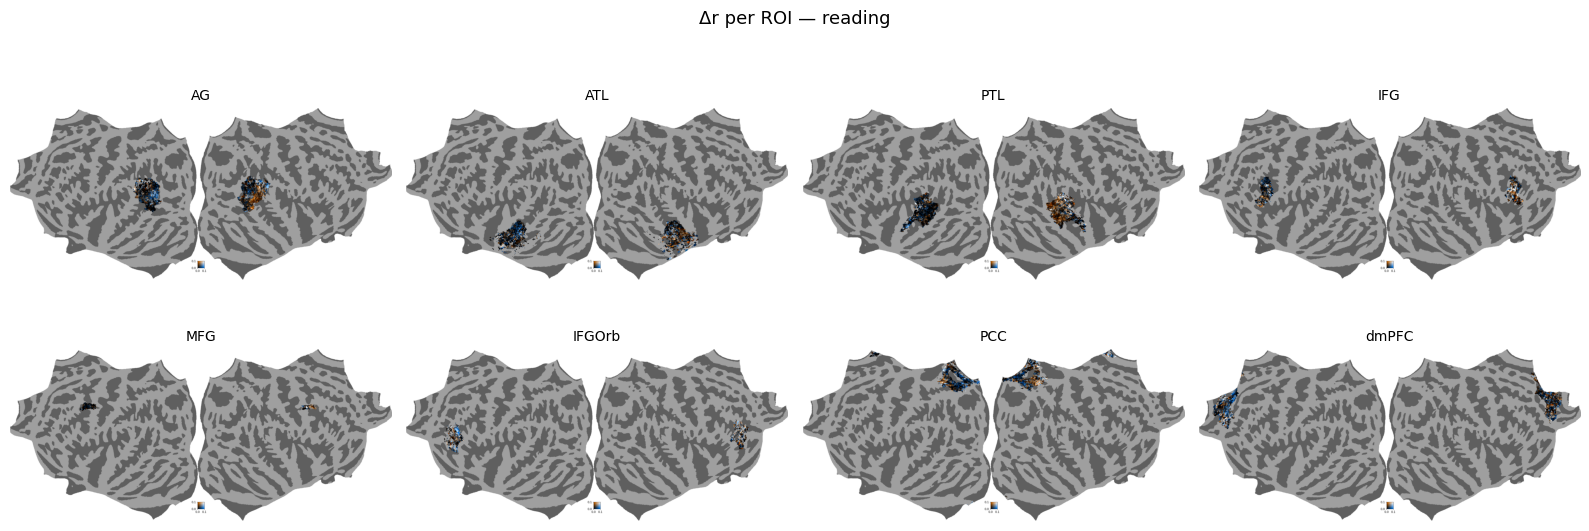

In [36]:
fig = plot_winner_map_per_roi(
    modality='reading',
    rois=language_rois,
    output_path=root_dir /'docs' / 'figures'/'Tests'/ 'winner_map_per_roi_.pdf',
)
plt.show()

## FLATMAPS

In [7]:
subject_code = {
    'subject01': 'S1',
    'subject02': 'S2',
    'subject03': 'S3',
    'subject04': 'S4',
    'subject05': 'S5',
    'subject06': 'S6',
    'subject07': 'S7',
    'subject08': 'S8',
    'subject09': 'S9',
}
def plot_bivariate(
    modality, 
    subject, 
    results_dir, 
    output_dir, 
    output_filename, 
    title='',
    legend=False,
    roi=False,
    size = 1
):
    results = file_io.load_results(
            root_dir / config.OUTPUT_DIR / results_dir,
            modality,
            subject
        )
    baseline = get_significant_voxels(results, 'baseline')
    
    nouns = baseline - get_significant_voxels(results, 'noun')
    verbs = baseline - get_significant_voxels(results, 'verb')
    
    
    # baseline = results['baseline']['r']
    # nouns = baseline - results['remove-pos-noun']['r']
    # verbs = baseline - results['remove-pos-verb']['r']
    from plotting_utils import BivariateStrategy
    fig_config = FigureConfig(
        figsize=(1.25, 0.7),
        smooth=False,
        show=True,
        show_regions=roi,
        save= True,
        output_dir=output_dir
    )
    mapper = FlatmapMapper(subject, root_dir/config.MAPPER_PATH)
    plotter = FlatmapPlotter(mapper, fig_config)
    _ = plotter.plot(
        [nouns, verbs],

        strategy=BivariateStrategy(vmax=0.1, labels=['nouns', 'verbs']),
        output_filename = output_filename,
        title=title,
        subject=subject_code[subject],
        builder_kwargs = {'show_legend': legend},
        #background_color = (0,0,0)
    )

def plot_bivariate2(
    modality, 
    modes,
    subject, 
    results_dir, 
    output_dir, 
    output_filename, 
    title='',
    legend=False,
    size = 1
):
    results = file_io.load_results(
            root_dir / config.OUTPUT_DIR / results_dir,
            modality,
            subject
        )
    mode = {}
    for m in modes:
        mode[m] = get_significant_voxels(results, m)

    # baseline = results['baseline']['r']
    # nouns = baseline - results['remove-pos-noun']['r']
    # verbs = baseline - results['remove-pos-verb']['r']
    from plotting_utils import BivariateStrategy
    fig_config = FigureConfig(
        figsize=(size*250/72, size*150/72),
        smooth=False,
        show=True,
        show_regions=False,
        save= True,
        output_dir=output_dir
    )
    mapper = FlatmapMapper(subject, root_dir/config.MAPPER_PATH)
    plotter = FlatmapPlotter(mapper, fig_config)
    _ = plotter.plot(
        [mode[modes[0]], mode[modes[1]]],

        strategy=BivariateStrategy(vmax=0.5, labels=[modes[0], modes[1]]),
        output_filename = output_filename,
        title=title,
        subject=subject_code[subject],
        builder_kwargs = {'show_legend': legend},
        #background_color = (0,0,0)
    )

def plot_contrast(
    modality,
    subject, 
    results_dir, 
    output_dir, 
    output_filename, 
    title='',
    legend=False,
    size = 1
):
    results = file_io.load_results(
            root_dir / config.OUTPUT_DIR / results_dir,
            modality,
            subject
        )
    nouns = get_significant_voxels(results, 'noun') 
    verbs = get_significant_voxels(results, 'verb') 
    baseline = get_significant_voxels(results, 'baseline')
    from plotting_utils import ContrastStrategy
    fig_config = FigureConfig(
        figsize=(size*250/72, size*150/72),
        smooth=False,
        show=True,
        show_regions=False,
        save= True,
        output_dir=output_dir
    )
    mapper = FlatmapMapper(subject, root_dir/config.MAPPER_PATH)
    plotter = FlatmapPlotter(mapper, fig_config)
    _ = plotter.plot(
        [baseline, nouns],
        strategy=ContrastStrategy(vmin=-0.1, vmax=0.1),
        output_filename = output_filename,
        title=title,
        subject=subject_code[subject],
        builder_kwargs = {'show_legend': legend},
        #background_color = (0,0,0)
    )

def plot_colored(
    modality, 
    subject, 
    results_dir, 
    output_dir, 
    output_filename, 
    title="",
    legend=False,
    roi=False
):
    results = file_io.load_results(
            root_dir / config.OUTPUT_DIR / results_dir,
            modality,
            subject
        )
    # baseline = get_significant_voxels(results, 'baseline')
    # nouns = baseline - get_significant_voxels(results, 'remove-pos-noun')
    # verbs = baseline - get_significant_voxels(results, 'remove-pos-verb')

    # baseline = results['baseline']['r']
    # nouns = results['remove-pos-noun']['r']
    # verbs = results['remove-pos-verb']['r']
    # adj = results['remove-pos-adj']['r']
    # adv = results['remove-pos-adv']['r']
    # pron = results['remove-pos-pron']['r']
    # intj = results['remove-pos-intj']['r']
    
    baseline = get_significant_voxels(results, 'baseline')
    nouns = get_significant_voxels(results, 'noun')
    verbs = get_significant_voxels(results, 'verb')
    adj = get_significant_voxels(results, 'adj')
    adv = get_significant_voxels(results, 'adv')
    pron = get_significant_voxels(results, 'pron')
    intj = get_significant_voxels(results, 'intj')

    fig_config = FigureConfig(
        figsize=(250/72, 150/72),
        smooth=False,
        show=True,
        show_regions=roi,
        save= True,
        output_dir=output_dir
    )
    mapper = FlatmapMapper(subject, root_dir/config.MAPPER_PATH)
    plotter = FlatmapPlotter(mapper, fig_config)
    _ = plotter.plot(
        [nouns, verbs, adj, adv, pron, intj, baseline],
        strategy=LoserTakesItAllStrategy(names=['Nouns', 'Verbs', 'Adjectives', 'Adverbs', 'Pronouns', 'Interjections']),
        output_filename = output_filename,
        builder_kwargs = {'show_legend': legend},
        title = title,
        subject=subject_code[subject],
        #background_color = (0,0,0)
    )

def plot_heatmap(modality, subject, mode, results_dir, output_dir, output_filename, title=''):
    results = file_io.load_results(
            root_dir / config.OUTPUT_DIR / results_dir,
            modality,
            subject
        )
    data = get_significant_voxels(results, mode)
    fig_config = FigureConfig(
        figsize=(1.25, 0.7),
        smooth=False,
        show=False,
        show_regions=False,
        save= True,
        output_dir=output_dir
    )
    print(data.shape)
    mapper = FlatmapMapper(subject, root_dir/config.MAPPER_PATH)
    plotter = FlatmapPlotter(mapper, fig_config)
    _ = plotter.plot(
        [data],
        strategy=SingleCorrelationStrategy(),
        output_filename = output_filename,
        title=title,
        subject=subject_code[subject],
        builder_kwargs = {'show_legend': True},
        # background_color = (0,0,0)
    )

In [6]:
for subject in config.SUBJECTS:
    results = file_io.load_results( 
        root_dir / config.OUTPUT_DIR / 'results_actual',
        'listening',
        subject
    )
    nouns = get_significant_voxels(results, 'noun')
    verbs = get_significant_voxels(results, 'verb')
    baseline = get_significant_voxels(results, 'baseline')
    
    d_nouns = baseline - nouns
    d_verbs = baseline - verbs
    
    m_nouns = np.nanmean(nouns)
    m_verbs = np.nanmean(verbs)
    m_baseline = np.nanmean(baseline)
    min_d_noun = np.nanmin(d_nouns)
    min_d_verb = np.nanmin(d_verbs)
    max_d_noun = np.nanmax(d_nouns)
    max_d_verb = np.nanmax(d_verbs)
    print(f"{subject_code[subject]}: \n Mean: noun={m_nouns:.4f}, verb={m_verbs:.4f}, baseline={m_baseline:.4f} \n Diff: noun =[{min_d_noun:.4f}, {max_d_noun:.4f}], verb =[{min_d_verb:.4f}, {max_d_verb:.4f}]")

S1: 
 Mean: noun=0.1903, verb=0.1899, baseline=0.1970 
 Diff: noun =[-0.2278, 0.2524], verb =[-0.2901, 0.2191]
S2: 
 Mean: noun=0.2022, verb=0.2042, baseline=0.2088 
 Diff: noun =[-0.2993, 0.3018], verb =[-0.2666, 0.2500]
S3: 
 Mean: noun=0.2009, verb=0.2012, baseline=0.2075 
 Diff: noun =[-0.2528, 0.2241], verb =[-0.2396, 0.3242]
S4: 
 Mean: noun=0.2129, verb=0.2103, baseline=0.2174 
 Diff: noun =[-0.1289, 0.1803], verb =[-0.2430, 0.2573]
S5: 
 Mean: noun=0.2062, verb=0.2061, baseline=0.2093 
 Diff: noun =[-0.1799, 0.2166], verb =[-0.2283, 0.2440]
S6: 
 Mean: noun=0.2059, verb=0.2022, baseline=0.2101 
 Diff: noun =[-0.2188, 0.2191], verb =[-0.1538, 0.2273]
S7: 
 Mean: noun=0.2089, verb=0.2169, baseline=0.2161 
 Diff: noun =[-0.2239, 0.3133], verb =[-0.3375, 0.3185]
S8: 
 Mean: noun=0.2101, verb=0.2089, baseline=0.2127 
 Diff: noun =[-0.3312, 0.2069], verb =[-0.2532, 0.2289]
S9: 
 Mean: noun=0.2129, verb=0.2090, baseline=0.2162 
 Diff: noun =[-0.1876, 0.2762], verb =[-0.2621, 0.2264]


### Contextual verb vs noun

[[nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 ...
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]]


/Users/simoneesposito/Desktop/Uni/WiSe 25_26 FINAL BOSS/nonsense/.venv/lib/python3.10/site-packages/matplotlib/colorizer.py:191: RuntimeWarning: invalid value encountered in cast
  xx = (xx * 255).astype(np.uint8)


Saved to ../docs/figures/Presentation/subject07-listening-all.pdf


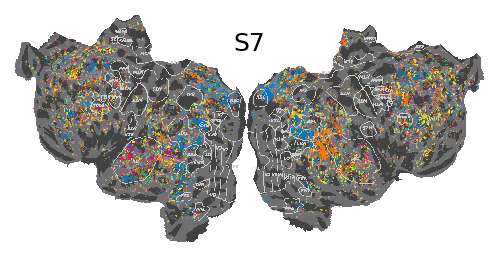

In [34]:
plot_colored(
    modality='listening',
    subject='subject07',
    results_dir='results_actual',
    output_dir = root_dir / 'docs'/'figures'/'Presentation',
    output_filename='subject07-listening-all.pdf',
    #title = 'POS Sensitivity, Listening',
    legend=False,
    roi=True
)

In [8]:
mode = 'baseline'
plot_heatmap(
        modality=modality,
        subject=subject,
        mode=mode,
        results_dir='results_actual',
        output_dir=root_dir / 'docs' / 'figures' / 'Sup1',
        output_filename=f"baseline.pdf",
        #title=f"Listening {mode.capitalize()} (r)"
    )

(85277,)
[[nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 ...
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]]


/Users/simoneesposito/Desktop/Uni/WiSe 25_26 FINAL BOSS/nonsense/.venv/lib/python3.10/site-packages/matplotlib/colorizer.py:191: RuntimeWarning: invalid value encountered in cast
  xx = (xx * 255).astype(np.uint8)


Saved to ../docs/figures/Sup1/baseline.pdf


In [24]:
mode = 'baseline'
for modality in ['listening', 'reading']:
    for subject in config.SUBJECTS:
        print(f"Plotting {subject}...")
        try:
            plot_heatmap(
                modality=modality,
                subject=subject,
                mode=mode,
                results_dir='results_actual',
                output_dir=root_dir / 'docs' / 'figures' / 'Sup1',
                output_filename=f"baseline-{modality}-{subject}.pdf",
    
                #title=f"Listening {mode.capitalize()} (r)"
            )
        except Exception as e:
            print(f"Failed to plot {subject}: {e}")

Plotting subject01...
(81133,)
[[nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 ...
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]]


/Users/simoneesposito/Desktop/Uni/WiSe 25_26 FINAL BOSS/nonsense/.venv/lib/python3.10/site-packages/matplotlib/colorizer.py:191: RuntimeWarning: invalid value encountered in cast
  xx = (xx * 255).astype(np.uint8)


Saved to ../docs/figures/Sup1/baseline-listening-subject01.pdf
Plotting subject02...
(80350,)
[[nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 ...
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]]


/Users/simoneesposito/Desktop/Uni/WiSe 25_26 FINAL BOSS/nonsense/.venv/lib/python3.10/site-packages/matplotlib/colorizer.py:191: RuntimeWarning: invalid value encountered in cast
  xx = (xx * 255).astype(np.uint8)


Saved to ../docs/figures/Sup1/baseline-listening-subject02.pdf
Plotting subject03...
(72965,)
[[nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 ...
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]]


...

/Users/simoneesposito/Desktop/Uni/WiSe 25_26 FINAL BOSS/nonsense/.venv/lib/python3.10/site-packages/matplotlib/colorizer.py:191: RuntimeWarning: invalid value encountered in cast
  xx = (xx * 255).astype(np.uint8)


Saved to ../docs/figures/Sup1/baseline-reading-subject07.pdf
Plotting subject08...
(79936,)
[[nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 ...
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]]


/Users/simoneesposito/Desktop/Uni/WiSe 25_26 FINAL BOSS/nonsense/.venv/lib/python3.10/site-packages/matplotlib/colorizer.py:191: RuntimeWarning: invalid value encountered in cast
  xx = (xx * 255).astype(np.uint8)


Saved to ../docs/figures/Sup1/baseline-reading-subject08.pdf
Plotting subject09...
(85277,)
[[nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 ...
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]]
Saved to ../docs/figures/Sup1/baseline-reading-subject09.pdf


/Users/simoneesposito/Desktop/Uni/WiSe 25_26 FINAL BOSS/nonsense/.venv/lib/python3.10/site-packages/matplotlib/colorizer.py:191: RuntimeWarning: invalid value encountered in cast
  xx = (xx * 255).astype(np.uint8)


In [ ]:
file_io.load_features('trn', config.FEATURES_FILE, )

In [15]:
for subject in config.SUBJECTS:
    for modality in ['listening', 'reading']:
        results = file_io.load_results(
            root_dir / config.OUTPUT_DIR / 'results_control',
            modality,
            subject
        )
        try:
            results['noun'] = results.pop('remove-pos-noun')
            results['verb'] = results.pop('remove-pos-verb')
            np.save(root_dir/config.OUTPUT_DIR/'results_control'/modality/f'{subject}.npy', results)
        except KeyError as e:
            print(f"Error occurred while processing {subject} for {modality}: {e}")

Error occurred while processing subject01 for listening: 'remove-pos-noun'
Error occurred while processing subject01 for reading: 'remove-pos-noun'
Error occurred while processing subject02 for listening: 'remove-pos-noun'
Error occurred while processing subject02 for reading: 'remove-pos-noun'
Error occurred while processing subject07 for listening: 'remove-pos-noun'


[[nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 ...
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]]


/Users/simoneesposito/Desktop/Uni/WiSe 25_26 FINAL BOSS/nonsense/.venv/lib/python3.10/site-packages/matplotlib/colorizer.py:191: RuntimeWarning: invalid value encountered in cast
  xx = (xx * 255).astype(np.uint8)


Saved to ../docs/figures/Sup2/listening-control-subject02.pdf


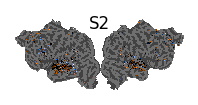

[[nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 ...
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]]
Saved to ../docs/figures/Sup2/reading-control-subject02.pdf


/Users/simoneesposito/Desktop/Uni/WiSe 25_26 FINAL BOSS/nonsense/.venv/lib/python3.10/site-packages/matplotlib/colorizer.py:191: RuntimeWarning: invalid value encountered in cast
  xx = (xx * 255).astype(np.uint8)


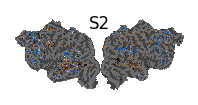

In [9]:
modality='reading'
for modality in ['listening', 'reading']:
    for subject in config.SUBJECTS[1:2]:
        try:
            plot_bivariate(
                modality=modality,
                subject=subject,
                results_dir="results_control",
                output_dir = root_dir / 'docs'/'figures'/'Sup2',
                output_filename=f'{modality}-control-{subject}.pdf',
                #title = f'Noun vs. Verb, {modality.capitalize()}',
                legend = False,
                roi=False,
            )
        except Exception as e:
            print(f"Failed to plot {subject} for {modality}: {e}")


[[nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 ...
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]]


/Users/simoneesposito/Desktop/Uni/WiSe 25_26 FINAL BOSS/nonsense/.venv/lib/python3.10/site-packages/matplotlib/colorizer.py:191: RuntimeWarning: invalid value encountered in cast
  xx = (xx * 255).astype(np.uint8)


Saved to ../docs/figures/Presentation/subject07-listening-noun-drop.pdf


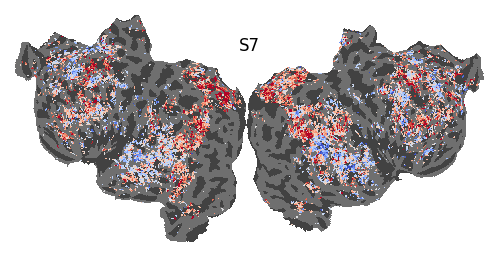

In [ ]:
modality='listening'
plot_contrast(
    modality=modality,
    subject='subject07',
    results_dir="results_actual",
    output_dir = root_dir / 'docs'/'figures'/'Presentation',
    output_filename=f'subject07-listening-noun-drop.pdf',
    #title = 'Verb vs. Baseline, Listening',
    legend = False,
    size = 1
)


Plotting subject01 listening...
Saved to ../docs/figures/Fig3/subject01-listening.pdf


/Users/simoneesposito/Desktop/Uni/WiSe 25_26 FINAL BOSS/nonsense/.venv/lib/python3.10/site-packages/matplotlib/colorizer.py:191: RuntimeWarning: invalid value encountered in cast
  xx = (xx * 255).astype(np.uint8)


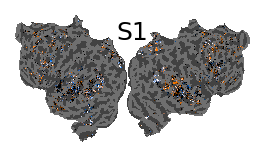

Plotting subject02 listening...
Error plotting subject02 listening: 'verb'
Plotting subject03 listening...
Saved to ../docs/figures/Fig3/subject03-listening.pdf


/Users/simoneesposito/Desktop/Uni/WiSe 25_26 FINAL BOSS/nonsense/.venv/lib/python3.10/site-packages/matplotlib/colorizer.py:191: RuntimeWarning: invalid value encountered in cast
  xx = (xx * 255).astype(np.uint8)


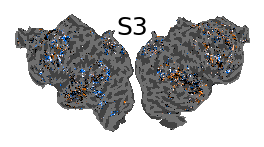

Plotting subject04 listening...
Saved to ../docs/figures/Fig3/subject04-listening.pdf


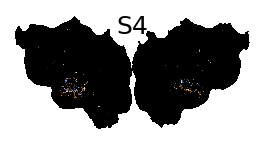

Plotting subject05 listening...
Saved to ../docs/figures/Fig3/subject05-listening.pdf


/Users/simoneesposito/Desktop/Uni/WiSe 25_26 FINAL BOSS/nonsense/.venv/lib/python3.10/site-packages/matplotlib/colorizer.py:191: RuntimeWarning: invalid value encountered in cast
  xx = (xx * 255).astype(np.uint8)


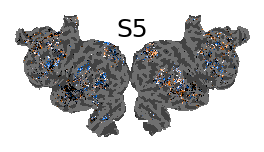

Plotting subject06 listening...
Saved to ../docs/figures/Fig3/subject06-listening.pdf


/Users/simoneesposito/Desktop/Uni/WiSe 25_26 FINAL BOSS/nonsense/.venv/lib/python3.10/site-packages/matplotlib/colorizer.py:191: RuntimeWarning: invalid value encountered in cast
  xx = (xx * 255).astype(np.uint8)


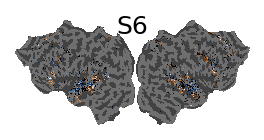

Plotting subject08 listening...


/Users/simoneesposito/Desktop/Uni/WiSe 25_26 FINAL BOSS/nonsense/.venv/lib/python3.10/site-packages/matplotlib/colorizer.py:191: RuntimeWarning: invalid value encountered in cast
  xx = (xx * 255).astype(np.uint8)


Saved to ../docs/figures/Fig3/subject08-listening.pdf


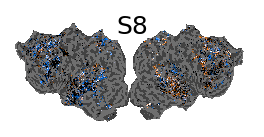

Plotting subject09 listening...
Saved to ../docs/figures/Fig3/subject09-listening.pdf


/Users/simoneesposito/Desktop/Uni/WiSe 25_26 FINAL BOSS/nonsense/.venv/lib/python3.10/site-packages/matplotlib/colorizer.py:191: RuntimeWarning: invalid value encountered in cast
  xx = (xx * 255).astype(np.uint8)


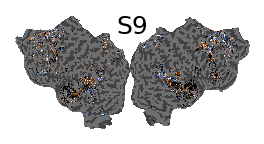

In [206]:
for subject in config.SUBJECTS:
    if subject == 'subject07':
        continue
    try:
        print(f"Plotting {subject} listening...")
        plot_bivariate(
            modality='listening',
            subject=subject,
            results_dir='results_actual',
            output_dir = root_dir / 'docs'/'figures'/'Fig3',
            output_filename = f'{subject}-listening.pdf',
            legend = False,
            size = 0.5
        )
    except Exception as e:
        print(f"Error plotting {subject} listening: {e}")
        

### Lexical verb vs noun

In [ ]:
for subject in config.SUBJECTS[6:7]:
    if subject == 'subject04':
        continue
    results = file_io.load_results(
            root_dir / config.OUTPUT_DIR / "results_control",
            'listening',
            subject
        )
    baseline = get_significant_voxels(results, 'baseline')
    nouns = baseline - get_significant_voxels(results, 'remove-pos-pct-noun')
    verbs = baseline - get_significant_voxels(results, 'remove-pos-pct-verb')
    
    # baseline = results['baseline']['r']
    # nouns = baseline - results['remove-pos-pct-noun']['r']
    # verbs = baseline - results['remove-pos-pct-verb']['r']
    from plotting_utils import BivariateStrategy
    fig_config = FigureConfig(
        figsize=(12, 8),
        smooth=False,
        show=True,
        show_regions=True,
        save= False,
        output_dir=root_dir / config.IMAGES_DIR/ modality / "Lexical2D"
    )
    mapper = FlatmapMapper(subject, root_dir/config.MAPPER_PATH)
    plotter = FlatmapPlotter(mapper, fig_config)
    _ = plotter.plot(
        [nouns, verbs],

        strategy=BivariateStrategy(vmax=0.1, labels=['nouns', 'verbs']),
        title = f'Nouns vs Verbs | {subject} | Lexical',
        output_filename = f'{subject}.png'
    )

## BAR PLOT

In [56]:
import spacy
import matplotlib.pyplot as plt
from collections import defaultdict

def analyze_pos(text, pos_tags):
    """Analyze parts of speech in text and return percentages."""
    doc = nlp(text)
    pos_counts = defaultdict(int)
    
    for token in doc:
        if token.pos_ in pos_tags:
            pos_counts[token.pos_] += 1
    
    total = sum(pos_counts.values())
    
    percentages = {tag: (pos_counts[tag] / total * 100) if total > 0 else 0 for tag in pos_tags}
    
    return percentages

In [57]:
nlp = spacy.load("en_core_web_sm")

# Sample stories (replace with your actual data)
stories = file_io.load_dataseqs(root_dir / config.DATASEQ_PATH, config.STORIES)
stories = {'story ' + str(i): ' '.join(v.data) for i, v in enumerate(stories.values())}

In [58]:
pos = {}
pos_tags = ['NOUN', 'VERB', 'ADJ', 'ADV', 'PRON', 'INTJ', 'PROPN', 'AUX']
for story_name, text in stories.items():
    pos[story_name] = analyze_pos(text, pos_tags)

# Prepare data for plotting
story_names = list(pos.keys())
nouns = [pos[s]["NOUN"]+pos[s]["PROPN"] for s in story_names]
verbs = [pos[s]["VERB"]+pos[s]["AUX"] for s in story_names]
adjectives = [pos[s]["ADJ"] for s in story_names]
adverbs = [pos[s]["ADV"] for s in story_names]
pronouns = [pos[s]["PRON"] for s in story_names]
interjections = [pos[s]["INTJ"] for s in story_names]

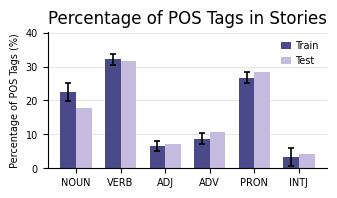

In [67]:
# Create bar chart that shows the percentage (y-axis) of each POS tag (x-axis) with its standard deviation (error bars)
# it should show two bars per POS tag: one for the average percentage across all stories except the last one, and one for the last story
import numpy as np
labels = ['NOUN', 'VERB', 'ADJ', 'ADV', 'PRON', 'INTJ']
x = np.arange(len(labels))  # the label locations
width = 0.35  # the width of the bars
averages = [
    np.mean(nouns[:-1]), 
    np.mean(verbs[:-1]), 
    np.mean(adjectives[:-1]), 
    np.mean(adverbs[:-1]), 
    np.mean(pronouns[:-1]), 
    np.mean(interjections[:-1])
]
std_devs = [
    np.std(nouns[:-1]), 
    np.std(verbs[:-1]),
    np.std(adjectives[:-1]),
    np.std(adverbs[:-1]),
    np.std(pronouns[:-1]),
    np.std(interjections[:-1])
]
last_story = [
    nouns[-1],
    verbs[-1],
    adjectives[-1],
    adverbs[-1],
    pronouns[-1],
    interjections[-1]
]
fig, ax = plt.subplots(figsize=(250/72, 150/72))

rects1 = ax.bar(
    x - width/2, averages, width,
    yerr=std_devs,
    label="Train",
    color="#4a4a8a",
    error_kw={"ecolor": "black", "elinewidth": 1.2, "capsize": 2.5, "capthick": 1.2},
)
rects2 = ax.bar(
    x + width/2, last_story, width,
    label="Test",
    color="#c5bbdf",
)

ax.set_ylabel("Percentage of POS Tags (%)", fontsize=7)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=7)
ax.tick_params(axis="y", labelsize=7)
ax.set_ylim(0, max(max(averages), max(last_story)) * 1.25)
ax.set_title('Percentage of POS Tags in Stories', fontsize=12)
ax.spines[["top", "right"]].set_visible(False)
ax.yaxis.grid(True, linewidth=0.4, color="lightgray", zorder=0)
ax.set_axisbelow(True)

ax.legend(
    fontsize=7, frameon=False,
    loc="upper right",
    handlelength=1, handletextpad=0.4,
)

plt.tight_layout()
plt.savefig(
    root_dir / "docs" / "figures" / "Fig2" / "pos_distribution.pdf",
    format="pdf", bbox_inches="tight"
)
plt.show()

## DROP PLOT

In [ ]:
def compute_margin(corr, baseline):
    stacked = np.stack(corr, axis=0)
    stacked-= baseline
    worst_indices = np.argsort(stacked, axis=0)[0]
    second_worst_indices = np.argsort(stacked, axis=0)[1]

    worst_vals = stacked[worst_indices, np.arange(stacked.shape[1])]
    second_worst_vals = stacked[second_worst_indices, np.arange(stacked.shape[1])]

    margin = second_worst_vals- worst_vals
    return margin

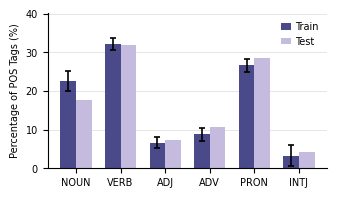

In [189]:
labels = ['NOUN', 'VERB', 'ADJ', 'ADV', 'PRON', 'INTJ']
x = np.arange(len(labels))
width = 0.35

averages = [np.mean(nouns[:-1]), np.mean(verbs[:-1]), np.mean(adjectives[:-1]),
            np.mean(adverbs[:-1]), np.mean(pronouns[:-1]), np.mean(interjections[:-1])]
std_devs = [np.std(nouns[:-1]), np.std(verbs[:-1]), np.std(adjectives[:-1]),
            np.std(adverbs[:-1]), np.std(pronouns[:-1]), np.std(interjections[:-1])]
last_story = [nouns[-1], verbs[-1], adjectives[-1], adverbs[-1], pronouns[-1], interjections[-1]]

fig, ax = plt.subplots(figsize=(250/72, 150/72))

ax.bar(x - width/2, averages, width, yerr=std_devs, label="Train",
       color="#4a4a8a", error_kw={"ecolor": "black", "elinewidth": 1.2,
                                   "capsize": 2.5, "capthick": 1.2})
ax.bar(x + width/2, last_story, width, label="Test", color="#c5bbdf")

ax.set_ylabel("Percentage of POS Tags (%)", fontsize=7)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=7)
ax.tick_params(axis="y", labelsize=7)
ax.set_ylim(0, max(max(averages), max(last_story)) * 1.25)
ax.spines[["top", "right"]].set_visible(False)
ax.yaxis.grid(True, linewidth=0.4, color="lightgray", zorder=0)
ax.set_axisbelow(True)
ax.legend(fontsize=7, frameon=False, loc="upper right",
          handlelength=1, handletextpad=0.4)

plt.tight_layout()
plt.savefig(root_dir / "docs" / "figures" / "Fig2" / "pos_distribution.pdf",
            format="pdf", bbox_inches="tight")
plt.show()

# Correlations

In [146]:
data = {}
for modality in ['listening', 'reading']:
    data[modality] = []
    for subject in config.SUBJECTS:
        results = file_io.load_results(
            root_dir / config.OUTPUT_DIR / "results_actual",
            modality,
            subject
        )
        baseline = get_significant_voxels(results, 'baseline')
        data[modality].append(baseline)
        

In [55]:
max_r = np.nanmax([np.nanmax(d) for d in data])
max_r

np.float32(0.60874724)

In [47]:
mean_r = np.array([np.nanmean(d) for d in data])
print(mean_r.mean())
print(mean_r.std())


0.2003174
0.0075956164


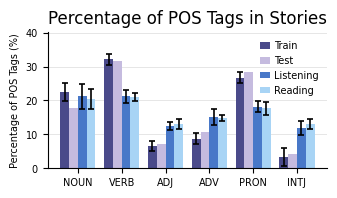

In [184]:
labels = ['NOUN', 'VERB', 'ADJ', 'ADV', 'PRON', 'INTJ']
x = np.arange(len(labels))
width = 0.2  # narrower to fit 4 bars

averages = [np.mean(nouns[:-1]), np.mean(verbs[:-1]), np.mean(adjectives[:-1]),
            np.mean(adverbs[:-1]), np.mean(pronouns[:-1]), np.mean(interjections[:-1])]
std_devs = [np.std(nouns[:-1]), np.std(verbs[:-1]), np.std(adjectives[:-1]),
            np.std(adverbs[:-1]), np.std(pronouns[:-1]), np.std(interjections[:-1])]
last_story = [nouns[-1], verbs[-1], adjectives[-1], adverbs[-1], pronouns[-1], interjections[-1]]

listening_means = np.mean(pct['listening'], axis=0)  # shape: (6,)
listening_stds  = np.std(pct['listening'], axis=0)
reading_means   = np.mean(pct['reading'], axis=0)
reading_stds    = np.std(pct['reading'], axis=0)

error_kw_dark  = {"elinewidth": 1.2, "capsize": 2.5, "capthick": 1.2}

fig, ax = plt.subplots(figsize=(250/72, 150/72))

ax.bar(x - 1.5*width, averages,        width, yerr=std_devs,        label="Train",     color="#4a4a8a", error_kw={"ecolor": "black", **error_kw_dark})
ax.bar(x - 0.5*width, last_story,      width,                        label="Test",      color="#c5bbdf")
ax.bar(x + 0.5*width, listening_means, width, yerr=listening_stds,  label="Listening", color="#4878C8", error_kw={"ecolor": "black", **error_kw_dark})
ax.bar(x + 1.5*width, reading_means,   width, yerr=reading_stds,    label="Reading",   color="#a8d4f5", error_kw={"ecolor": "black", **error_kw_dark})

ax.set_ylabel("Percentage of POS Tags (%)", fontsize=7)
ax.set_title('Percentage of POS Tags in Stories', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=7)
ax.tick_params(axis="y", labelsize=7)
ax.set_ylim(0, max(max(averages), max(last_story), max(listening_means), max(reading_means)) * 1.25)
ax.spines[["top", "right"]].set_visible(False)
ax.yaxis.grid(True, linewidth=0.4, color="lightgray", zorder=0)
ax.set_axisbelow(True)
ax.legend(fontsize=7, frameon=False, loc="upper right", handlelength=1, handletextpad=0.4)

plt.tight_layout()
plt.savefig(root_dir / "docs" / "figures" / "Fig2" / "pos_distribution.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [172]:
pct['listening']

array([[18.22199773, 23.76562697, 14.78722061, 13.62545776, 17.09811845,
        12.50157848],
       [23.46528366, 21.44369179, 13.00804403, 11.02878916, 19.89839119,
        11.15580017],
       [16.55480984, 17.37509321, 13.12453393, 17.22595078, 20.13422819,
        15.58538404],
       [23.18077365, 23.13289927, 12.23669092, 15.46342398, 15.27192646,
        10.71428571],
       [18.20444444, 20.92444444, 12.97777778, 17.61777778, 18.63111111,
        11.64444444],
       [28.13808131, 20.3624061 , 11.6004358 , 12.13945754, 18.20631917,
         9.55330007],
       [23.96370068, 19.78005076, 10.76674614, 15.35799431, 16.2424056 ,
        13.88910251],
       [18.46121461, 23.08178087, 11.24092201, 18.33491211, 19.74528997,
         9.13588043]])

In [182]:
print("Listening:")
for mode in modes:
    print(f"  {mode}: {pct['listening'][:, modes.index(mode)].mean():.2f}% ± {pct['listening'][:, modes.index(mode)].std():.2f}%")
print("\nReading:")
for mode in modes:
    print(f"  {mode}: {pct['reading'][:, modes.index(mode)].mean():.2f}% ± {pct['reading'][:, modes.index(mode)].std():.2f}%")

Listening:
  noun: 21.27% ± 3.74%
  verb: 21.23% ± 1.98%
  adj: 12.47% ± 1.20%
  adv: 15.10% ± 2.48%
  pron: 18.15% ± 1.69%
  intj: 11.77% ± 2.03%

Reading:
  noun: 20.35% ± 2.92%
  verb: 21.05% ± 1.22%
  adj: 13.02% ± 1.53%
  adv: 14.88% ± 0.96%
  pron: 17.66% ± 1.99%
  intj: 13.05% ± 1.35%


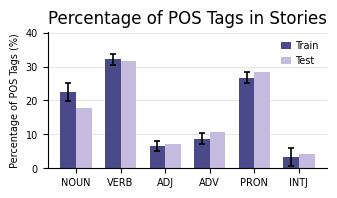

In [ ]:
# Create bar chart that shows the percentage (y-axis) of each POS tag (x-axis) with its standard deviation (error bars)
# it should show two bars per POS tag: one for the average percentage across all stories except the last one, and one for the last story
import numpy as np
labels = ['NOUN', 'VERB', 'ADJ', 'ADV', 'PRON', 'INTJ']
x = np.arange(len(labels))  # the label locations
width = 0.35  # the width of the bars
averages = [
    np.mean(nouns[:-1]), 
    np.mean(verbs[:-1]), 
    np.mean(adjectives[:-1]), 
    np.mean(adverbs[:-1]), 
    np.mean(pronouns[:-1]), 
    np.mean(interjections[:-1])
]
std_devs = [
    np.std(nouns[:-1]), 
    np.std(verbs[:-1]),
    np.std(adjectives[:-1]),
    np.std(adverbs[:-1]),
    np.std(pronouns[:-1]),
    np.std(interjections[:-1])
]
last_story = [
    nouns[-1],
    verbs[-1],
    adjectives[-1],
    adverbs[-1],
    pronouns[-1],
    interjections[-1]
]
fig, ax = plt.subplots(figsize=(250/72, 150/72))

rects1 = ax.bar(
    x - width/2, averages, width,
    yerr=std_devs,
    label="Train",
    color="#4a4a8a",
    error_kw={"ecolor": "black", "elinewidth": 1.2, "capsize": 2.5, "capthick": 1.2},
)
rects2 = ax.bar(
    x + width/2, last_story, width,
    label="Test",
    color="#c5bbdf",
)

ax.set_ylabel("Percentage of POS Tags (%)", fontsize=7)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=7)
ax.tick_params(axis="y", labelsize=7)
ax.set_ylim(0, max(max(averages), max(last_story)) * 1.25)
ax.set_title('Percentage of POS Tags in Stories', fontsize=12)
ax.spines[["top", "right"]].set_visible(False)
ax.yaxis.grid(True, linewidth=0.4, color="lightgray", zorder=0)
ax.set_axisbelow(True)

ax.legend(
    fontsize=7, frameon=False,
    loc="upper right",
    handlelength=1, handletextpad=0.4,
)

plt.tight_layout()
plt.savefig(
    root_dir / "docs" / "figures" / "Fig2" / "pos_distribution.pdf",
    format="pdf", bbox_inches="tight"
)
plt.show()

# R and SE

In [5]:
results_list = {}
results_read = {}

for subject in config.SUBJECTS:
    results_list[subject] = file_io.load_results(
        root_dir / config.OUTPUT_DIR / 'results_actual',
        'listening',
        subject
    )
    results_read[subject] = file_io.load_results(
        root_dir / config.OUTPUT_DIR / 'results_actual',
        'reading',
        subject
    )

In [11]:
r_list = {s: np.nanmean(get_significant_voxels(results_list[s], 'baseline')) for s in config.SUBJECTS}
r_read = {s: np.nanmean(get_significant_voxels(results_read[s], 'baseline')) for s in config.SUBJECTS}

In [13]:
vals_list = np.array(list(r_list.values()))
vals_read = np.array(list(r_read.values()))

mean_list = np.nanmean(vals_list)
se_list = np.nanstd(vals_list, ddof=1) / np.sqrt(np.sum(~np.isnan(vals_list)))

mean_read = np.nanmean(vals_read)
se_read = np.nanstd(vals_read, ddof=1) / np.sqrt(np.sum(~np.isnan(vals_read)))

In [16]:
se_list

np.float64(0.0020845623997350535)

In [17]:
se_read

np.float64(0.0028483939046661058)